# t-분포로 확장한 실험 모음

In [39]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"  # 한글 깨짐 방지 (Windows 기본 한글 폰트)
plt.rcParams["axes.unicode_minus"] = False

## 1. mode 정의

In [40]:
means = np.array([
    [-1.5,  1.5],
    [ 1.5,  1.5],
    [-1.5, -1.5],
])
sigma = 0.6
weights = np.array([1 / 3, 1 / 3, 1 / 3])

## 2. 밀도 함수 $p(x)$ 와 스코어 함수 $\nabla_x \log p(x)$

In [41]:
import math

df_mix = 3  # t-분포 혼합의 자유도 (작을수록 꼬리가 두꺼움, df>2 필요)

def density(x1, x2, w=None, df=df_mix):
    """이 파일의 주 모델: t-분포 혼합 밀도."""
    if w is None:
        w = weights
    C = math.gamma((df + 2) / 2) / (math.gamma(df / 2) * df * np.pi * sigma ** 2)
    p = np.zeros_like(x1)
    for wk, mu in zip(w, means):
        d2 = (x1 - mu[0]) ** 2 + (x2 - mu[1]) ** 2
        p += wk * C * (1 + d2 / (df * sigma ** 2)) ** (-(df + 2) / 2)
    return p

def score(x1, x2, w=None, df=df_mix):
    """이 파일의 주 모델: t-분포 혼합 스코어."""
    if w is None:
        w = weights
    p = density(x1, x2, w=w, df=df)
    C = math.gamma((df + 2) / 2) / (math.gamma(df / 2) * df * np.pi * sigma ** 2)
    grad_x1 = np.zeros_like(x1)
    grad_x2 = np.zeros_like(x2)
    for wk, mu in zip(w, means):
        d2 = (x1 - mu[0]) ** 2 + (x2 - mu[1]) ** 2
        n_k = wk * C * (1 + d2 / (df * sigma ** 2)) ** (-(df + 2) / 2)
        responsibility = n_k / p
        factor = -(df + 2) / (df * sigma ** 2 + d2)
        grad_x1 += responsibility * factor * (x1 - mu[0])
        grad_x2 += responsibility * factor * (x2 - mu[1])
    return grad_x1, grad_x2

## 3. 격자 준비

In [42]:
lim = 4

fine = np.linspace(-lim, lim, 300)
X1_fine, X2_fine = np.meshgrid(fine, fine)
P = density(X1_fine, X2_fine)

coarse = np.linspace(-lim, lim, 18)
X1_c, X2_c = np.meshgrid(coarse, coarse)
U, V = score(X1_c, X2_c)
magnitude = np.sqrt(U ** 2 + V ** 2)

### 3-1. 시각화: 밀도 $p(x)$ 와 스코어 $\nabla_x \log p(x)$

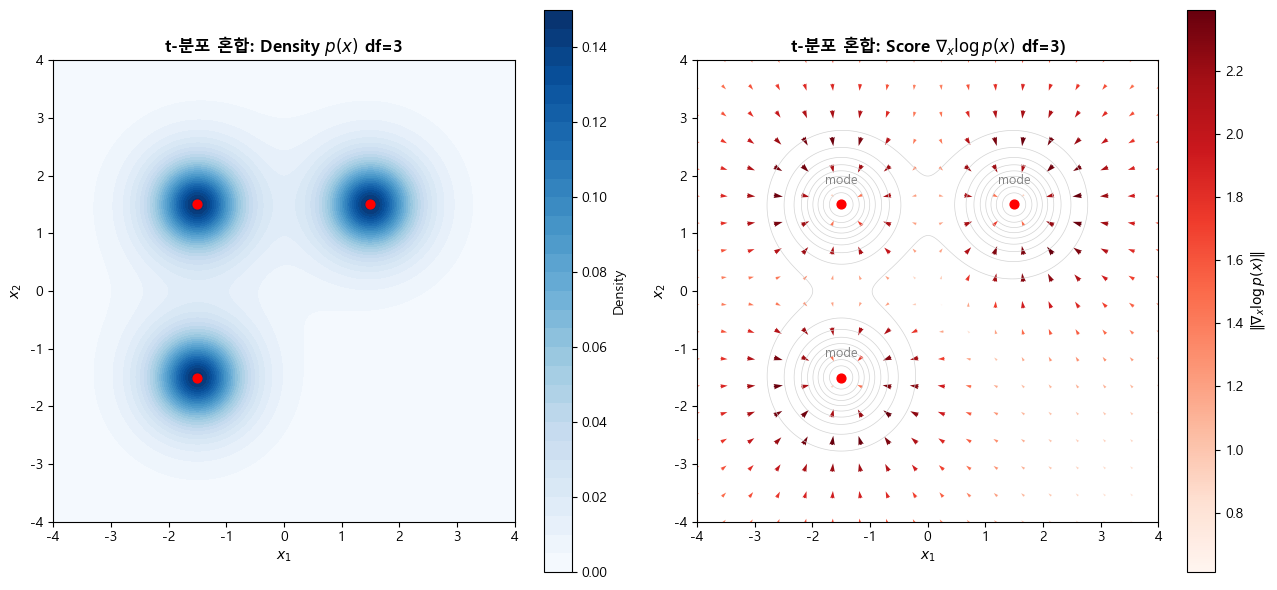

In [50]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

cf = ax1.contourf(X1_fine, X2_fine, P, levels=30, cmap='Blues')
cbar1 = fig.colorbar(cf, ax=ax1)
cbar1.set_label('Density')
ax1.scatter(means[:, 0], means[:, 1], c='red', s=40, zorder=5)
ax1.set_title(r't-분포 혼합: Density $p(x)$ df=' + str(df_mix) , fontweight='bold')
ax1.set_xlabel(r'$x_1$')
ax1.set_ylabel(r'$x_2$')
ax1.set_xlim(-lim, lim)
ax1.set_ylim(-lim, lim)
ax1.set_aspect('equal')

ax2.contour(X1_fine, X2_fine, P, levels=10, colors='lightgray', linewidths=0.5)
q = ax2.quiver(
    X1_c, X2_c, U, V, magnitude,
    cmap='Reds', scale=120, width=0.005, pivot='mid',
)
cbar2 = fig.colorbar(q, ax=ax2)
cbar2.set_label(r'$\|\nabla_x \log p(x)\|$')
ax2.scatter(means[:, 0], means[:, 1], c='red', s=40, zorder=5)
for mu in means:
    ax2.annotate('mode', (mu[0], mu[1] + 0.35), ha='center', color='gray', fontsize=9)
ax2.set_title(r't-분포 혼합: Score $\nabla_x \log p(x)$ df=' + str(df_mix) + ')', fontweight='bold')
ax2.set_xlabel(r'$x_1$')
ax2.set_ylabel(r'$x_2$')
ax2.set_xlim(-lim, lim)
ax2.set_ylim(-lim, lim)
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

## 4. 점들이 스코어를 따라 이동하면?

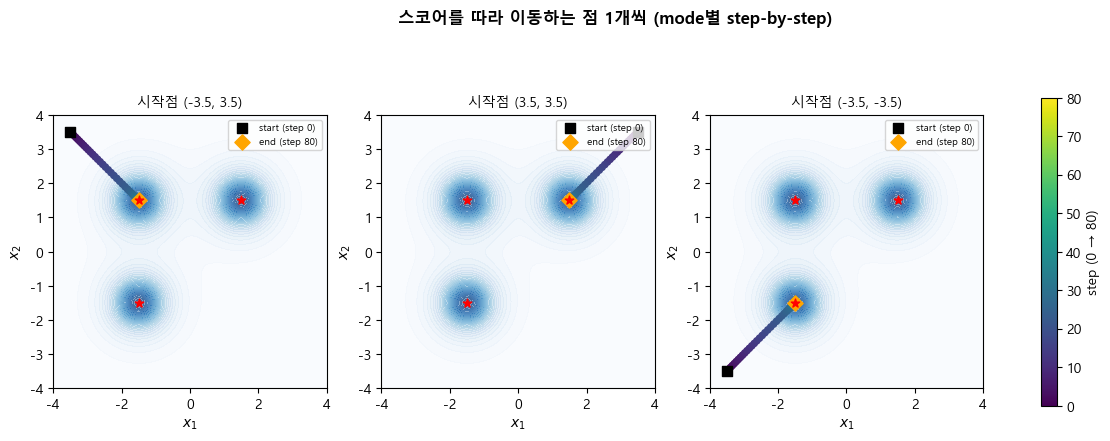

In [43]:
def follow_score(start_points, step_size=0.05, n_steps=80, noise_scale=0.0, noise_df=None, score_fn=None, rng=None):
    """x_{t+1} = x_t + step_size * score_fn(x_t) + noise_scale * noise
    noise_scale=0 이면 순수 gradient ascent.
    noise_df=None 이면 노이즈가 정규분포, 숫자를 주면 그 자유도의 t-분포(분산은 noise_scale^2으로 맞춤).
    score_fn을 안 주면 위에서 정의한 가우시안 혼합 score()를 쓴다 (다른 밀도의 score를 넣어도 됨)."""
    if score_fn is None:
        score_fn = score
    if rng is None:
        rng = np.random.default_rng(0)
    trajectories = np.zeros((n_steps + 1, *start_points.shape))
    trajectories[0] = start_points
    x = start_points.copy()
    for t in range(n_steps):
        gx, gy = score_fn(x[:, 0], x[:, 1])
        grad = np.stack([gx, gy], axis=1)
        if noise_scale > 0:
            if noise_df is not None:
                raw = rng.standard_t(noise_df, size=x.shape)
                noise = raw * (noise_scale / np.sqrt(noise_df / (noise_df - 2)))
            else:
                noise = rng.normal(scale=noise_scale, size=x.shape)
        else:
            noise = 0.0
        x = x + step_size * grad + noise
        trajectories[t + 1] = x
    return trajectories

start_points = np.array([
    [-3.5,  3.5],   # -> mode (-1.5, 1.5) 방향
    [ 3.5,  3.5],   # -> mode ( 1.5, 1.5) 방향
    [-3.5, -3.5],   # -> mode (-1.5,-1.5) 방향
])
step_size_demo = 0.05
n_steps_demo = 80
trajectories = follow_score(start_points, step_size=step_size_demo, n_steps=n_steps_demo, noise_scale=0.0)
step_idx = np.arange(n_steps_demo + 1)

fig3, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, ax in enumerate(axes):
    ax.contourf(X1_fine, X2_fine, P, levels=30, cmap="Blues", alpha=0.5)
    ax.plot(trajectories[:, i, 0], trajectories[:, i, 1], color="gray", alpha=0.4, linewidth=1, zorder=3)
    sc = ax.scatter(
        trajectories[:, i, 0], trajectories[:, i, 1],
        c=step_idx, cmap="viridis", s=20, zorder=4,
    )
    ax.scatter(*start_points[i], c="black", s=60, marker="s", zorder=5, label="start (step 0)")
    ax.scatter(*trajectories[-1, i], c="orange", s=60, marker="D", zorder=5, label=f"end (step {n_steps_demo})")
    ax.scatter(means[:, 0], means[:, 1], c="red", s=40, marker="*", zorder=5)
    ax.legend(loc="upper right", fontsize=7)
    ax.set_title(f"시작점 ({start_points[i, 0]}, {start_points[i, 1]})", fontsize=10)
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")

fig3.colorbar(sc, ax=axes, shrink=0.8, label="step (0 → 80)")
fig3.suptitle("스코어를 따라 이동하는 점 1개씩 (mode별 step-by-step)", fontweight="bold")

plt.show()

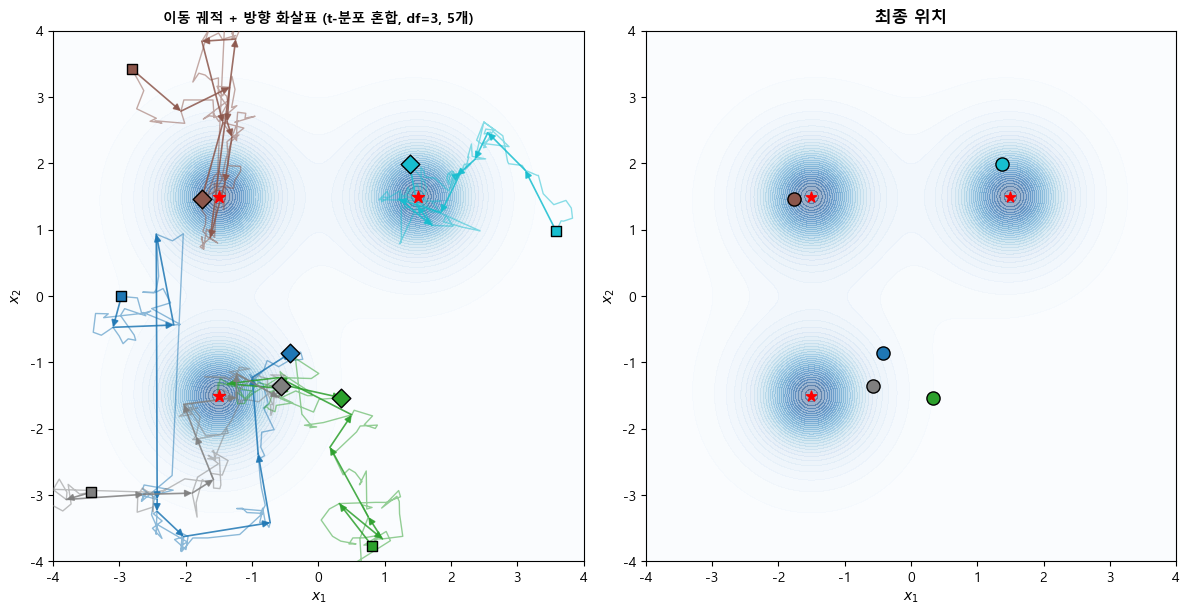

In [44]:
step_size_t = 0.02
n_steps_langevin_t = 100
n_particles_langevin_t = 5
noise_df_langevin = 3  # 노이즈도 t-분포(자유도 3)로

rng4 = np.random.default_rng(11)
start_points_lt = rng4.uniform(-lim, lim, size=(n_particles_langevin_t, 2))
trajectories_lt = follow_score(
    start_points_lt,
    step_size=step_size_t,
    n_steps=n_steps_langevin_t,
    noise_scale=np.sqrt(2 * step_size_t),
    noise_df=noise_df_langevin,
    rng=rng4,
)
final_points_lt = trajectories_lt[-1]

colors_t = plt.cm.tab10(np.linspace(0, 1, n_particles_langevin_t))
arrow_step_t = 10

fig5t, (axCt, axDt) = plt.subplots(1, 2, figsize=(12, 6))

axCt.contourf(X1_fine, X2_fine, P, levels=30, cmap='Blues', alpha=0.4)
for i in range(n_particles_langevin_t):
    axCt.plot(trajectories_lt[:, i, 0], trajectories_lt[:, i, 1], color=colors_t[i], alpha=0.5, linewidth=1, zorder=3)
    for t in range(0, n_steps_langevin_t, arrow_step_t):
        t_next = min(t + arrow_step_t, n_steps_langevin_t)
        x0, y0 = trajectories_lt[t, i]
        x1_, y1_ = trajectories_lt[t_next, i]
        axCt.annotate(
            '', xy=(x1_, y1_), xytext=(x0, y0),
            arrowprops=dict(arrowstyle='-|>', color=colors_t[i], alpha=0.85, lw=1.2, shrinkA=0, shrinkB=0),
            zorder=4,
        )
    axCt.scatter(*start_points_lt[i], color=colors_t[i], s=60, marker='s', zorder=5, edgecolor='black')
    axCt.scatter(*final_points_lt[i], color=colors_t[i], s=90, marker='D', zorder=6, edgecolor='black')
axCt.scatter(means[:, 0], means[:, 1], c='red', s=80, marker='*', zorder=7)
axCt.set_title(f'이동 궤적 + 방향 화살표 (t-분포 혼합, df={df_mix}, {n_particles_langevin_t}개)', fontweight='bold', fontsize=10)

axDt.contourf(X1_fine, X2_fine, P, levels=30, cmap='Blues', alpha=0.4)
for i in range(n_particles_langevin_t):
    axDt.scatter(*final_points_lt[i], color=colors_t[i], s=90, zorder=5, edgecolor='black')
axDt.scatter(means[:, 0], means[:, 1], c='red', s=60, marker='*', zorder=6)
axDt.set_title('최종 위치', fontweight='bold')

for ax in (axCt, axDt):
    ax.set_xlabel(r'$x_1$')
    ax.set_ylabel(r'$x_2$')
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

### 4-1. 100개로: 과정 없이 결과만

시작 개수 (mode별): [176, 166, 158]
최종 개수 (mode별): [176, 163, 161]

전이표 (행=출발 비율, 열=최종 mode)
              최종1  최종2  최종3
출발 비율 0.333333  126     17     33
출발 비율 0.333333   21    138      7
출발 비율 0.333333   29      8    121

시작 mode와 최종 mode가 다른 점: 115/500개
threshold(1.5) 벗어난 극단값: 67/500개


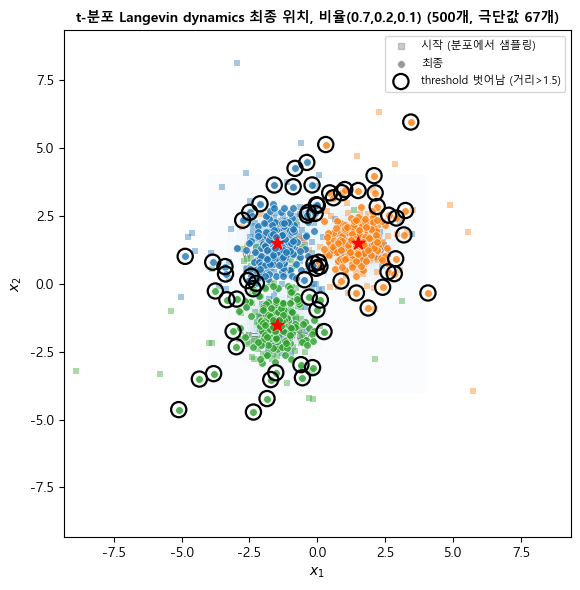

In [70]:
step_size = 0.02
n_steps_langevin = 100
n_particles_langevin = 500

weights_073 = np.array([1/3, 1/3, 1/3])  # <- 비율을 균등하게 하려면 이 줄로 교체
P_073 = density(X1_fine, X2_fine, w=weights_073)
score_073 = lambda x1, x2: score(x1, x2, w=weights_073)

rng5 = np.random.default_rng(11)
comp_idx_start = rng5.choice(len(means), size=n_particles_langevin, p=weights_073)
z_start = rng5.normal(size=(n_particles_langevin, 2))
v_start = rng5.chisquare(df_mix, size=n_particles_langevin)
start_points_l100 = means[comp_idx_start] + sigma * z_start / np.sqrt(v_start / df_mix)[:, None]

trajectories_l100 = follow_score(
    start_points_l100,
    step_size=step_size,
    n_steps=n_steps_langevin,
    noise_scale=np.sqrt(2 * step_size),
    score_fn=score_073,
    rng=rng5,
)
final_points_l100 = trajectories_l100[-1]

mode_colors = ['tab:blue', 'tab:orange', 'tab:green']
dist_to_modes = np.linalg.norm(final_points_l100[:, None, :] - means[None, :, :], axis=2)
labels_l100 = np.argmin(dist_to_modes, axis=1)

extreme_threshold_l100 = 1.5
final_dist_to_nearest = dist_to_modes.min(axis=1)
is_extreme_l100 = final_dist_to_nearest > extreme_threshold_l100

print('시작 개수 (mode별):', [int(np.sum(comp_idx_start == i)) for i in range(3)])
print('최종 개수 (mode별):', [int(np.sum(labels_l100 == i)) for i in range(3)])
print()
transition = np.zeros((3, 3), dtype=int)
for i in range(3):
    for j in range(3):
        transition[i, j] = int(np.sum((comp_idx_start == i) & (labels_l100 == j)))

row_labels = [f'출발 비율 {wk:g}' for wk in weights_073]
print('전이표 (행=출발 비율, 열=최종 mode)')
print('              최종1  최종2  최종3')
for i in range(3):
    row = '  '.join(f'{transition[i, j]:>5}' for j in range(3))
    print(f'{row_labels[i]:<14}{row}')
n_moved = int(np.sum(comp_idx_start != labels_l100))
print()
print(f'시작 mode와 최종 mode가 다른 점: {n_moved}/{n_particles_langevin}개')
print(f'threshold({extreme_threshold_l100}) 벗어난 극단값: {int(is_extreme_l100.sum())}/{n_particles_langevin}개')

lim_073 = max(lim, float(np.abs(start_points_l100).max()) * 1.05)

fig, ax = plt.subplots(figsize=(6, 6))
ax.contourf(X1_fine, X2_fine, P_073, levels=30, cmap='Blues', alpha=0.4)
for lbl in [0, 1, 2]:
    mask = labels_l100 == lbl
    color = mode_colors[lbl]
    ax.scatter(start_points_l100[mask, 0], start_points_l100[mask, 1], s=15, color=color, alpha=0.4, marker='s', linewidths=0)
    ax.scatter(final_points_l100[mask, 0], final_points_l100[mask, 1], s=30, color=color, alpha=0.8, edgecolor='white', linewidths=0.5, zorder=5)
ax.scatter(final_points_l100[is_extreme_l100, 0], final_points_l100[is_extreme_l100, 1], s=120, facecolors='none', edgecolors='black', linewidths=1.6, marker='o', zorder=6)
ax.scatter([], [], s=15, color='gray', alpha=0.4, marker='s', label='시작 (분포에서 샘플링)')
ax.scatter([], [], s=30, color='gray', alpha=0.8, edgecolor='white', linewidths=0.5, label='최종')
ax.scatter([], [], s=120, facecolors='none', edgecolors='black', linewidths=1.6, marker='o', label=f'threshold 벗어남 (거리>{extreme_threshold_l100})')
ax.scatter(means[:, 0], means[:, 1], c='red', s=90, marker='*', zorder=7)
for mu, wk in zip(means, weights_073):
    ax.annotate(f'w={wk:g}', (mu[0], mu[1] - 0.55), ha='center', color='gray', fontsize=9)
ax.set_title(f't-분포 Langevin dynamics 최종 위치, 비율(0.7,0.2,0.1) ({n_particles_langevin}개, 극단값 {int(is_extreme_l100.sum())}개)', fontweight='bold', fontsize=10)
ax.legend(loc='upper right', fontsize=8)
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.set_xlim(-lim_073, lim_073)
ax.set_ylim(-lim_073, lim_073)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### 4-2. 직접 샘플링하면 극단값이 얼마나 나올까?

500개 직접 샘플링 (비율 0.7/0.2/0.1)
평균 거리: 0.927   중간값: 0.751   최댓값: 5.241

threshold별 극단값(mode까지 거리 > threshold) 개수
threshold= 1.0:  173개 (34.6%)
threshold= 1.5:   73개 (14.6%)
threshold= 2.0:   33개 (6.6%)
threshold= 2.5:   17개 (3.4%)
threshold= 3.0:    8개 (1.6%)
threshold= 4.0:    4개 (0.8%)


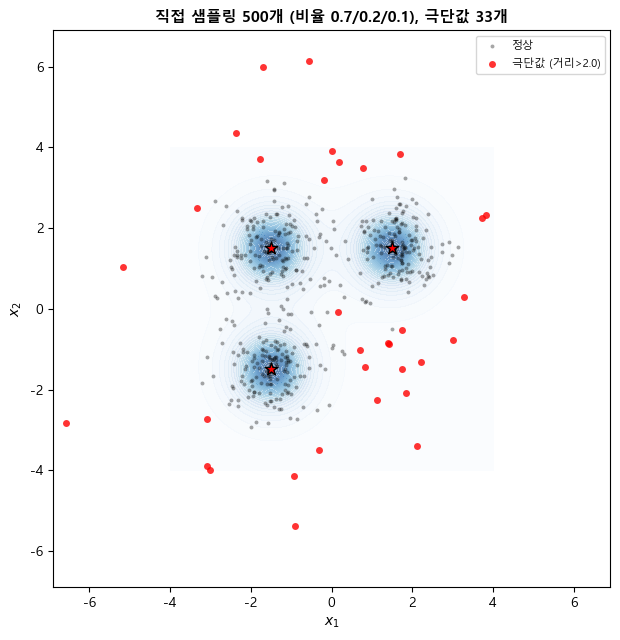

In [71]:
n_samples_ext = 500
rng6 = np.random.default_rng(3)
comp_idx_ext = rng6.choice(len(means), size=n_samples_ext, p=weights_073)
z_ext = rng6.normal(size=(n_samples_ext, 2))
v_ext = rng6.chisquare(df_mix, size=n_samples_ext)
samples_ext = means[comp_idx_ext] + sigma * z_ext / np.sqrt(v_ext / df_mix)[:, None]

dist_ext = np.min(np.linalg.norm(samples_ext[:, None, :] - means[None, :, :], axis=2), axis=1)

print(f'{n_samples_ext}개 직접 샘플링 (비율 0.7/0.2/0.1)')
print(f'평균 거리: {dist_ext.mean():.3f}   중간값: {np.median(dist_ext):.3f}   최댓값: {dist_ext.max():.3f}')
print()
print('threshold별 극단값(mode까지 거리 > threshold) 개수')
for thr in [1.0, 1.5, 2.0, 2.5, 3.0, 4.0]:
    n_ext_thr = int(np.sum(dist_ext > thr))
    print(f'threshold={thr:>4}: {n_ext_thr:>4}개 ({100*n_ext_thr/n_samples_ext:.1f}%)')

lim_ext = max(lim, float(np.abs(samples_ext).max()) * 1.05)

extreme_thr_plot = 2.0
is_extreme = dist_ext > extreme_thr_plot

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.contourf(X1_fine, X2_fine, P_073, levels=30, cmap='Blues', alpha=0.4)
ax.scatter(samples_ext[~is_extreme, 0], samples_ext[~is_extreme, 1], s=8, c='black', alpha=0.35, linewidths=0, label='정상')
ax.scatter(samples_ext[is_extreme, 0], samples_ext[is_extreme, 1], s=25, c='red', alpha=0.8, linewidths=0, label=f'극단값 (거리>{extreme_thr_plot})')
ax.scatter(means[:, 0], means[:, 1], c='red', s=90, marker='*', zorder=6, edgecolor='black')
ax.set_title(f'직접 샘플링 {n_samples_ext}개 (비율 0.7/0.2/0.1), 극단값 {int(is_extreme.sum())}개', fontweight='bold', fontsize=11)
ax.legend(loc='upper right', fontsize=8)
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.set_xlim(-lim_ext, lim_ext)
ax.set_ylim(-lim_ext, lim_ext)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 5. 노이즈를 정규분포 대신 t-분포로 바꾸면?

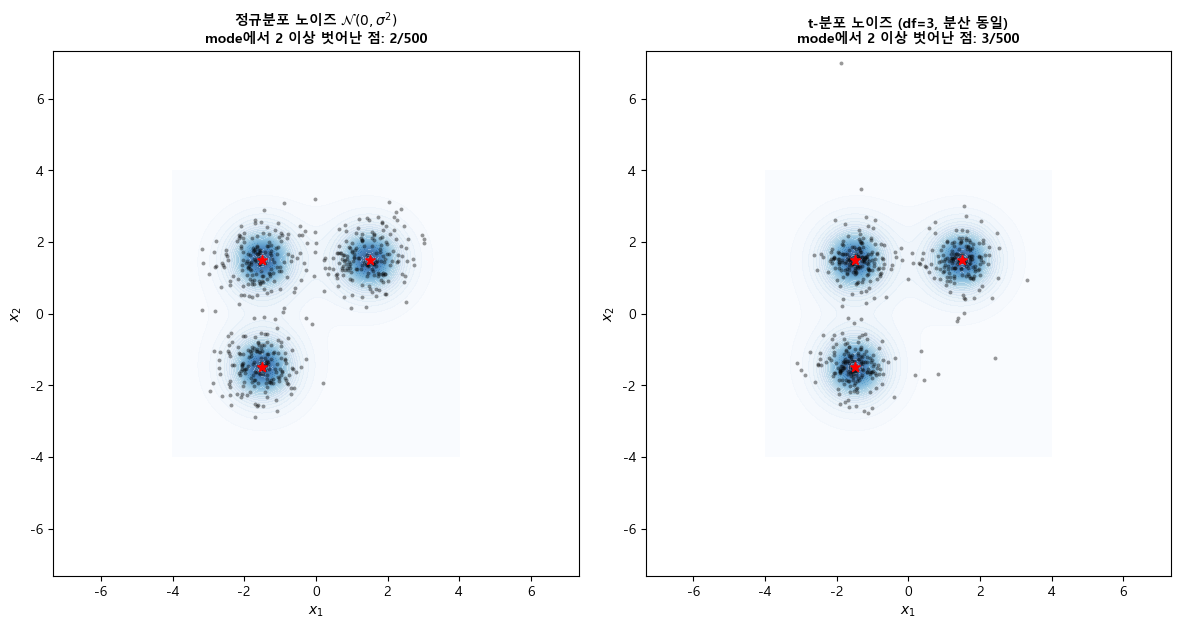

In [64]:
df_t = 3  # 자유도. 작을수록 꼬리가 두꺼워짐 (df>2 이어야 분산이 유한)
t_scale = sigma / np.sqrt(df_t / (df_t - 2))  # 분산을 sigma^2 으로 맞추기 위한 스케일

n_samples_t = 500
rng_t = np.random.default_rng(7)

comp_idx_normal = rng_t.choice(len(means), size=n_samples_t, p=weights)
samples_normal = means[comp_idx_normal] + rng_t.normal(scale=sigma, size=(n_samples_t, 2))

comp_idx_t = rng_t.choice(len(means), size=n_samples_t, p=weights)
samples_t = means[comp_idx_t] + rng_t.standard_t(df_t, size=(n_samples_t, 2)) * t_scale

lim_t = max(lim, float(np.abs(np.concatenate([samples_normal, samples_t])).max()) * 1.05)

extreme_threshold_5 = 2.0
dist_normal = np.min(np.linalg.norm(samples_normal[:, None, :] - means[None, :, :], axis=2), axis=1)
dist_t_direct = np.min(np.linalg.norm(samples_t[:, None, :] - means[None, :, :], axis=2), axis=1)
n_far_normal = int(np.sum(dist_normal > extreme_threshold_5))
n_far_t = int(np.sum(dist_t_direct > extreme_threshold_5))
print(f'mode에서 {extreme_threshold_5} 이상 벗어난 점 (극단값):')
print(f'  정규분포 노이즈: {n_far_normal}/{n_samples_t}개 ({100*n_far_normal/n_samples_t:.1f}%)')
print(f'  t-분포 노이즈:   {n_far_t}/{n_samples_t}개 ({100*n_far_t/n_samples_t:.1f}%)')

fig10, (axG, axH) = plt.subplots(1, 2, figsize=(12, 6))
for ax, s, title, n_far in [
    (axG, samples_normal, r'정규분포 노이즈 $\mathcal{N}(0,\sigma^2)$', n_far_normal),
    (axH, samples_t, f't-분포 노이즈 (df={df_t}, 분산 동일)', n_far_t),
]:
    ax.contourf(X1_fine, X2_fine, P, levels=30, cmap='Blues', alpha=0.5)
    ax.scatter(s[:, 0], s[:, 1], s=8, c='black', alpha=0.4, linewidths=0)
    ax.scatter(means[:, 0], means[:, 1], c='red', s=50, marker='*', zorder=5)
    ax.set_title(f'{title}' + chr(10) + f'mode에서 {extreme_threshold_5} 이상 벗어난 점: {n_far}/{n_samples_t}', fontweight='bold', fontsize=10)
    ax.set_xlabel(r'$x_1$')
    ax.set_ylabel(r'$x_2$')
    ax.set_xlim(-lim_t, lim_t)
    ax.set_ylim(-lim_t, lim_t)
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()